# Checkpoint 2 Data Processing and EDA

This document reports the protocol for preprocessing of Gene Expression Omnibus (GEO) data series. This workflow utilizes Simple Omnibus Format in Text (SOFT) files of GEO data series to compile gene expression values from Affymetrix microarrays. The data to be analyzed are of typical clinical microarray data consisting of patients grouped into an array of archetypes (e.g., rejection, non-rejection, etc).

Detailed programs and workflow for preprocessing can be found in the supporting notebooks and figure below (Figure 1). Briefly, gene expression microarray data was imported from GEO (e.g., GSE277334) and compiled samples into a dataframe with GEOparse and pandas. Probe IDs, i.e. single DNA locations on the array chip, are annotated with associated gene symbols. Unannotated Probes are discarded and the first associated gene symbols with annotated Probes are kept. Duplicated Probes were collapsed to a single gene symbol by taking the median of gene expression between duplicates to handle outliers more robustly than the mean. Before evaluating the data, we perform quality control protocols: 1) Principal component analysis to evaluate separation of differential expression between sample groups, 2) Relative Log Expression (RLE) for microarray deviation of expression intensity from the median transcript expression, and 3) “soft” intensity based filtering to remove probes barely above the “detection” limit. Finally, the dataframe is filtered on removing transcripts that do not have intensities greater than the threshold limit determined.

For implementation of missing value identifying and data imputing, please refer to ``Microarray_Processing.py`` under the ``Checkpoint2_Microarray_Processing`` folder. 

![diagram](../Checkpoint2_Microarray_Processing/Workflow.png)\
Figure 1: Data Processing and EDA workflow



## GEO Microarray Processing

In [7]:
# import packages
import GEOparse
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import logging
logging.getLogger("GEOparse").setLevel(logging.WARNING)


# 1 Import annotation data and microarray expression data

# Load the GSE dataset
gse = GEOparse.get_GEO("GSE277334")

# Print general info
print(gse.metadata)

# Access the GPL
gpl = list(gse.gpls.values())[0]


c:\Users\nanth\anaconda3\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


{'title': ['Defining an NK cell-enriched rejection-like phenotype in liver transplant biopsies from the INTERLIVER study'], 'geo_accession': ['GSE277334'], 'status': ['Public on Jul 03 2025'], 'submission_date': ['Sep 16 2024'], 'last_update_date': ['Jul 04 2025'], 'pubmed_id': ['39780312'], 'summary': ['Background: Initial analysis of liver transplant biopsies in the INTERLIVER study (#NCT03193151) using rejection-associated transcripts failed to find an antibody-mediated rejection state (i.e. rich in NK cells and with interferon-gamma effects). We recently developed an optimization strategy in lung transplants that isolated an NK cell-enriched rejection-like state (NKRL) that was molecularly distinct from T cell-mediated rejection (TCMR). Here we apply the same strategy to a liver transplant biopsy population.', 'Results: The full model classified 765 biopsies into the following molecular phenotypes, characterized by their gene expression: No-rejection (NR) 54%; TCMR 16%; NKRL 13%; a

## Compile all samples into Dataframe

In [8]:
# Define the columns you want to keep
columns_of_interest = [
    'ID', 
    'Gene Symbol', 
    'Gene Ontology Biological Process', 
    'Gene Ontology Cellular Component',
    'Gene Ontology Molecular Function', 
    'Pathway'
]

# Subset the table
gpl_subset = gpl.table[columns_of_interest]

# Check the first few rows
print(gpl_subset.head())

# Combine all samples into one DataFrame
all_expr = pd.concat([gsm.table['VALUE'] for gsm in gse.gsms.values()], axis=1)
all_expr.columns = gse.gsms.keys()
all_expr['ID_REF'] = list(list(gse.gsms.values())[0].table['ID_REF'])


              ID Gene Symbol  \
0    11715100_at    HIST1H3G   
1  11715101_s_at    HIST1H3G   
2  11715102_x_at    HIST1H3G   
3  11715103_x_at   TNFAIP8L1   
4  11715104_s_at       OTOP2   

                    Gene Ontology Biological Process  \
0  0006334 // nucleosome assembly // inferred fro...   
1  0006334 // nucleosome assembly // inferred fro...   
2  0006334 // nucleosome assembly // inferred fro...   
3                                                ---   
4                                                ---   

                    Gene Ontology Cellular Component  \
0  0000786 // nucleosome // inferred from electro...   
1  0000786 // nucleosome // inferred from electro...   
2  0000786 // nucleosome // inferred from electro...   
3                                                ---   
4  0016020 // membrane // inferred from electroni...   

                    Gene Ontology Molecular Function Pathway  
0  0003677 // DNA binding // inferred from electr...     ---  
1  0003

## Annotate Dataframe Probe IDs with associated Gene Symbols

In [9]:
# Merge expression data with gene symbols
expr_annotated = all_expr.merge(
    gpl_subset,
    left_on='ID_REF',
    right_on='ID',
    how='left'
)

# Clean up the gene symbols BEFORE setting as index
expr_annotated['Gene Symbol'] = (
    expr_annotated['Gene Symbol']
    .astype(str)                     # ensure all entries are strings
    .str.split(' /// ').str[0]       # keep only the first gene if multiple listed
    .str.strip()                     # remove any extra whitespace
)

# Filter out missing, placeholder, or literal "nan" entries
expr_annotated = expr_annotated[
    expr_annotated['Gene Symbol'].notna() &                      # real NaN values
    (expr_annotated['Gene Symbol'] != "---") &                   # placeholder
    (expr_annotated['Gene Symbol'].str.lower() != "nan")         # string "nan"
]


print(expr_annotated.head())



   GSM8519505  GSM8519506  GSM8519507  GSM8519508  GSM8519509  GSM8519510  \
0        3.90        3.58        3.61        3.65        3.34        3.57   
1        5.91        6.14        6.09        5.93        5.63        5.87   
2        4.14        3.77        3.62        3.73        3.56        3.66   
3        6.64        6.82        6.64        6.45        7.26        6.83   
4        5.49        5.75        5.38        5.32        5.75        5.49   

   GSM8519511  GSM8519512  GSM8519513  GSM8519514  ...  GSM8520265  \
0        3.67        3.75        3.76        3.75  ...        4.24   
1        6.53        6.01        6.21        6.03  ...        6.10   
2        3.90        3.84        3.83        3.84  ...        4.24   
3        6.77        6.90        6.70        6.82  ...        6.59   
4        5.52        5.64        5.62        5.64  ...        5.87   

   GSM8520266  GSM8520267         ID_REF             ID  Gene Symbol  \
0        5.21        3.89    11715100_at    

## Extract 1) sample and archetype, 2) Gene symbol annotations

In [10]:
# Extract sample and archetype
sample_info = []

for gsm_name, gsm in gse.gsms.items():
    characteristics = gsm.metadata.get('characteristics_ch1', [])
    
    # Find the cluster info
    cluster = None
    for char in characteristics:
        if "rejection archetype" in char.lower():
            parts = char.split(":", 1)
            if len(parts) > 1:
                cluster = parts[1].strip()  # take the part after colon

    sample_info.append({'Sample': gsm_name, 'Cluster': cluster})

sample_df = pd.DataFrame(sample_info)
sample_df.to_csv(r"./GSE277334_metadata.csv", index=False)

# Ensure the Gene Symbol column exists
if 'Gene Symbol' not in expr_annotated.columns:
    raise KeyError("Column 'Gene Symbol' not found in expr_annotated")

# Set 'Gene Symbol' as index for grouping
expr_annotated = expr_annotated.set_index('Gene Symbol')

# Expression-only matrix (numeric columns)
expr_values = expr_annotated.select_dtypes(include='number')

# Gene-level annotation (non-numeric columns)
gene_annotations = expr_annotated[
    [
        'Gene Ontology Biological Process',
        'Gene Ontology Cellular Component',
        'Gene Ontology Molecular Function',
        'Pathway'
    ]
].copy()

## Collapse Dataframe of duplicated Genes by median gene expression

In [11]:
# Remove duplicate annotation rows (keep first)
gene_annotations = gene_annotations[~gene_annotations.index.duplicated(keep='first')]

# Save both separately
# expr_values.to_csv(r"./GSE277334_expression_uncollapsed.csv") Save if needed to check for downstream errors
gene_annotations.to_csv(r"./GSE277334_gene_annotations.csv")

# Collapse expression values by taking the median per gene symbol
expr_collapsed = expr_values.groupby(expr_annotated.index).median()

#expr_collapsed.to_csv(r"./GSE277334_expression_collapsed.csv") Save if needed to check for downstream errors

print(f"Shape before: {expr_values.shape}, after collapsing: {expr_collapsed.shape}")

Shape before: (48774, 763), after collapsing: (19468, 763)


## Quality control processes

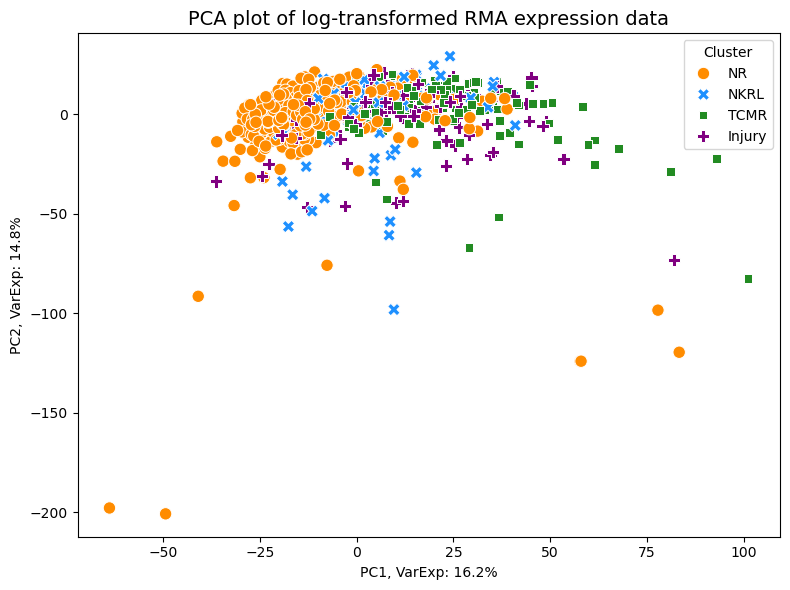

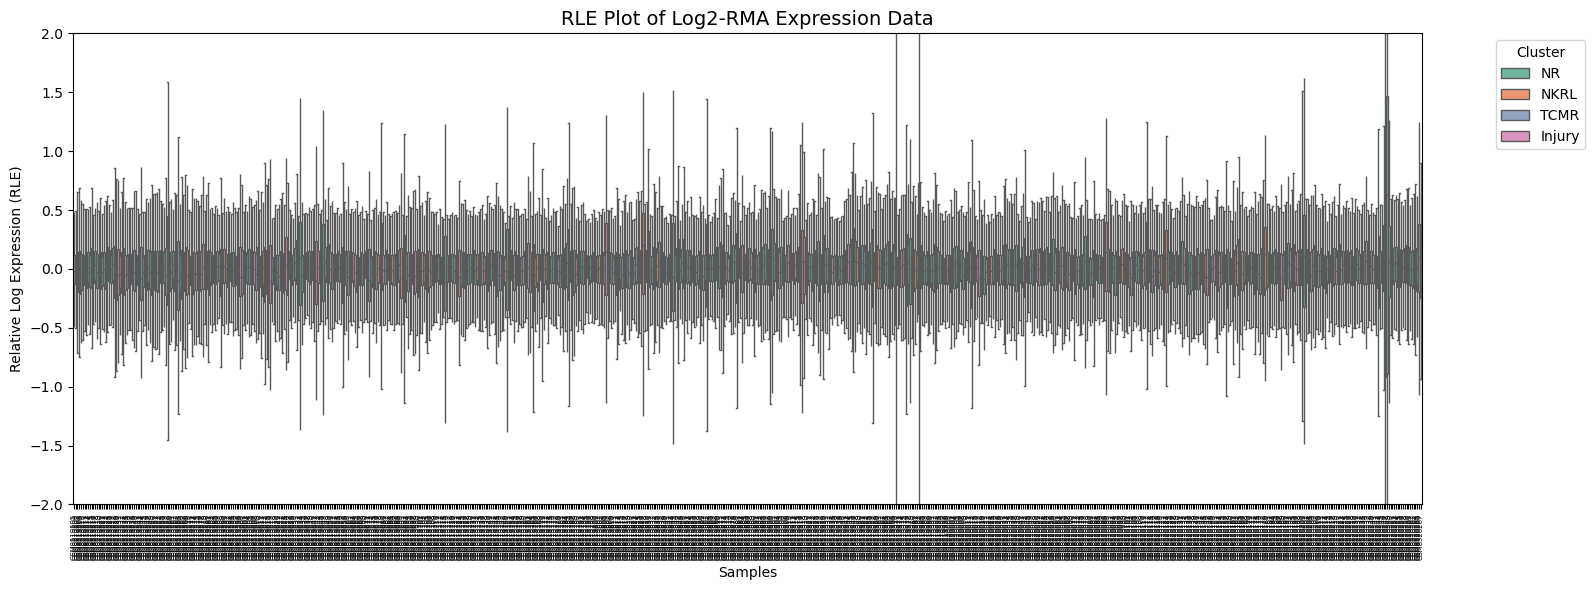

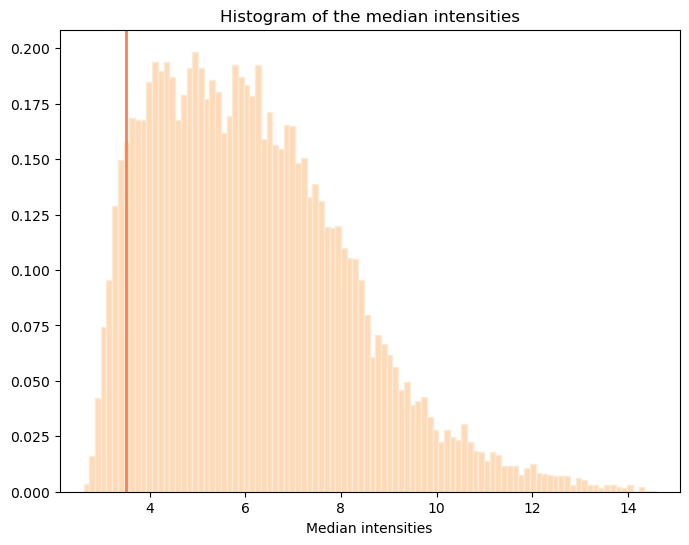

In [12]:
# Perform PCA on transposed data (samples as rows)
pca = PCA()
pca_raw = pca.fit_transform(expr_collapsed.T)

# Calculate variance explained by each PC
percent_var_raw = np.round(100 * pca.explained_variance_ratio_, 1)

# Create a DataFrame for plotting
dataGG_raw = pd.DataFrame({
    "PC1_raw": pca_raw[:, 0],
    "PC2_raw": pca_raw[:, 1],
    # Replace this with your actual cluster info — for example:
    # clusters = sample_metadata["Cluster"]
    # or extract from gse.gsms metadata
    "Cluster": sample_df["Cluster"]  
})

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=dataGG_raw,
    x="PC1_raw",
    y="PC2_raw",
    hue="Cluster",
    style="Cluster",
    s=80,
    palette=["darkorange", "dodgerblue", "forestgreen", "purple"]
)

plt.title("PCA plot of log-transformed RMA expression data", fontsize=14, ha='center')
plt.xlabel(f"PC1, VarExp: {percent_var_raw[0]}%")
plt.ylabel(f"PC2, VarExp: {percent_var_raw[1]}%")
plt.tight_layout()
plt.savefig(r"./GSE277334rawPCA.png", dpi=300)
plt.show()

## Box plot of log2 intensities RAW data

# Compute the median expression for each gene
gene_medians = expr_collapsed.median(axis=1)

# Compute RLE (subtract gene median from each sample)
rle_data = expr_collapsed.subtract(gene_medians, axis=0)

# Convert to long format for plotting
rle_long = rle_data.reset_index().melt(id_vars='Gene Symbol',
                                       var_name='Sample',
                                       value_name='RLE')

# Merge sample metadata (Cluster/Archetype)
rle_long = rle_long.merge(sample_df, left_on='Sample', right_on='Sample', how='left')

# Plot RLE using seaborn
plt.figure(figsize=(16, 6))
sns.boxplot(
    data=rle_long,
    x='Sample',
    y='RLE',
    hue='Cluster',  # or 'Archetype' if you want
    dodge=False,    # one box per sample
    showfliers=False,
    palette="Set2"
)

plt.ylim(-2, 2)
plt.xticks(rotation=90, fontsize=5)
plt.title("RLE Plot of Log2-RMA Expression Data", fontsize=14)
plt.xlabel("Samples")
plt.ylabel("Relative Log Expression (RLE)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(r"./GSE277334_BoxIntensities.png", dpi=300)
plt.show()


## Filtering on Intensity

# Compute row medians correctly
row_medians = expr_collapsed.median(axis=1).astype(float)  # <- force float

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(
    row_medians,
    bins=100,              # make sure enough bins
    color="peachpuff",
    edgecolor="antiquewhite",
    density=True
)
plt.title("Histogram of the median intensities")
plt.xlabel("Median intensities")
plt.xlim(row_medians.min() - 0.5, row_medians.max() + 0.5)

# Add threshold line
man_threshold = 3.5
plt.axvline(x=man_threshold, color="coral", linewidth=2)
plt.savefig(r"./GSE277334_HistoIntensities.png", dpi=300)
plt.show()


## Filter Dataframe from set intensity threshold

In [13]:
# Filtering by intensity
# Count number of samples in each cluster
no_of_samples = sample_df['Cluster'].value_counts()
print(no_of_samples)

# Minimum number of samples across clusters (samples_cutoff)
samples_cutoff = no_of_samples.min()
print(f"Samples cutoff: {samples_cutoff}")

# Filter genes: must have expression > man_threshold in at least samples_cutoff samples
idx_man_threshold = (expr_collapsed > man_threshold).sum(axis=1) >= samples_cutoff
print(idx_man_threshold.value_counts())  # True = genes kept, False = filtered out

# Subset filtered genes
chang_manfiltered = expr_collapsed[idx_man_threshold]
print(f"Number of genes before filtering: {expr_collapsed.shape[0]}")
print(f"Number of genes after filtering: {chang_manfiltered.shape[0]}")

chang_manfiltered.to_csv(r"./GSE277334_expression_collapsed_filtered.csv")
 

Cluster
NR        415
TCMR      125
Injury    125
NKRL       98
Name: count, dtype: int64
Samples cutoff: 98
True     18644
False      824
Name: count, dtype: int64
Number of genes before filtering: 19468
Number of genes after filtering: 18644


# Microarray Processing Overview

## GSE277334 Microarray processing
It was determined that imported gene expression microarray contained 763 samples of Non-rejection (415), T cell-mediate rejection (125), Injury (125), and NK cell-enriched rejection-like state (NKRL).

The starting gene expression array began with 48774 gene features before collapsing then 19468 features post-collapsing.

Furthermore, after gene filtering on theshold intensity the gene expression microarray was further reduced to 18644 features.

These dataframes ``GSE277334_metadata.csv``, ``GSE277334_gene_annotations.csv``, and``GSE277334_expression_collapsed_filtered.csv`` are available for data modeling and statistical analysis.